In [1]:
# libararies

# Tensorflow 2
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GaussianNoise, Dropout


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten


import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline  

from PIL import Image
import glob

import os
import random
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

from tensorflow.keras.models import Model

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.scorecam import Scorecam
from tf_keras_vis.activation_maximization import ActivationMaximization
from tf_keras_vis.activation_maximization.callbacks import Progress
from tf_keras_vis.activation_maximization.input_modifiers import Jitter, Rotate2D
from tf_keras_vis.activation_maximization.regularizers import TotalVariation2D, Norm
from tf_keras_vis.utils.model_modifiers import ExtractIntermediateLayer, ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore


w = 128
h = 128

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# limiting mem size
import tensorflow as tf
tf.config.optimizer.set_jit(False)
# Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
physical_devices = tf.config.list_physical_devices('GPU')
# Limit memory to a certain fraction (e.g., 4GB of GPU memory)
gpu_memory_limit = 750 # in MB, but week day 750 in MB
for device in physical_devices:
    tf.config.set_logical_device_configuration(
        device,
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=gpu_memory_limit)]
    )

2026-07-21 15:01:32.243063: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 15:01:32.292564: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-21 15:01:33.062061: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
# fix random seed for reproducibility
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)

# Load data
X =[]
Y =[]

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'} # this will account for all image extensions though we are only using .jpg

def list_images(folder):
    # case-insensitive, any extension in IMG_EXTS
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in IMG_EXTS]

for filename in list_images('train/Healthy'):
    im = Image.open(filename).convert('RGB')
    im = im.resize((w, h), Image.LANCZOS)
    arr = np.array(im)

    # add images and class to the two lists
    X.append(arr)
    Y.append(0)  # Healthy class

# same below
for filename in list_images('train/aculus_olearius'):
    im = Image.open(filename).convert('RGB')
    im = im.resize((w, h), Image.LANCZOS)
    arr = np.array(im)

    X.append(arr)
    Y.append(1)  # aculus_olearius class

for filename in list_images('train/olive_peacock_spot'):
    im = Image.open(filename).convert('RGB')
    im = im.resize((w, h), Image.LANCZOS)
    arr = np.array(im)

    X.append(arr)
    Y.append(2)  # olive_peacock_spot class


    
# Convert to NP array
X = np.array(X)


# reshape to be [samples][channels][width][height]
X = X.reshape(X.shape[0], w, h, 3).astype('float32')

# Normalize the data
X = X /255

# one hot encode outputs
Y = np.array(Y)

# randomize the data set - numpy arrays
randomize = np.arange(len(X))
np.random.shuffle(randomize)
X = X[randomize]
Y = Y[randomize]


Y = to_categorical(Y)
num_classes = Y.shape[1]

print("X:", X.shape, "| Y:", Y.shape, "| per-class:", Y.sum(axis=0))

X: (2720, 128, 128, 3) | Y: (2720, 3) | per-class: [ 830.  690. 1200.]


Healthy: 830, Aculus Olearius: 690, Olive Peacock Spot: 1200


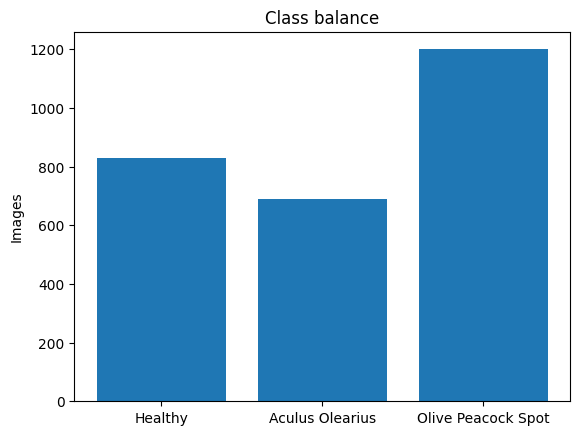

In [6]:
# Class representation

healthy_class = Y[:, 0] == 1
aculusOlearius_class = Y[:, 1] == 1
olivePeacockSpot_class = Y[:, 2] == 1
print(f"Healthy: {healthy_class.sum()}, Aculus Olearius: {aculusOlearius_class.sum()}, Olive Peacock Spot: {olivePeacockSpot_class.sum()}")

plt.bar(['Healthy', 'Aculus Olearius', 'Olive Peacock Spot'], [healthy_class.sum(), aculusOlearius_class.sum(), olivePeacockSpot_class.sum()])
plt.title('Class balance')
plt.ylabel('Images')
plt.show()

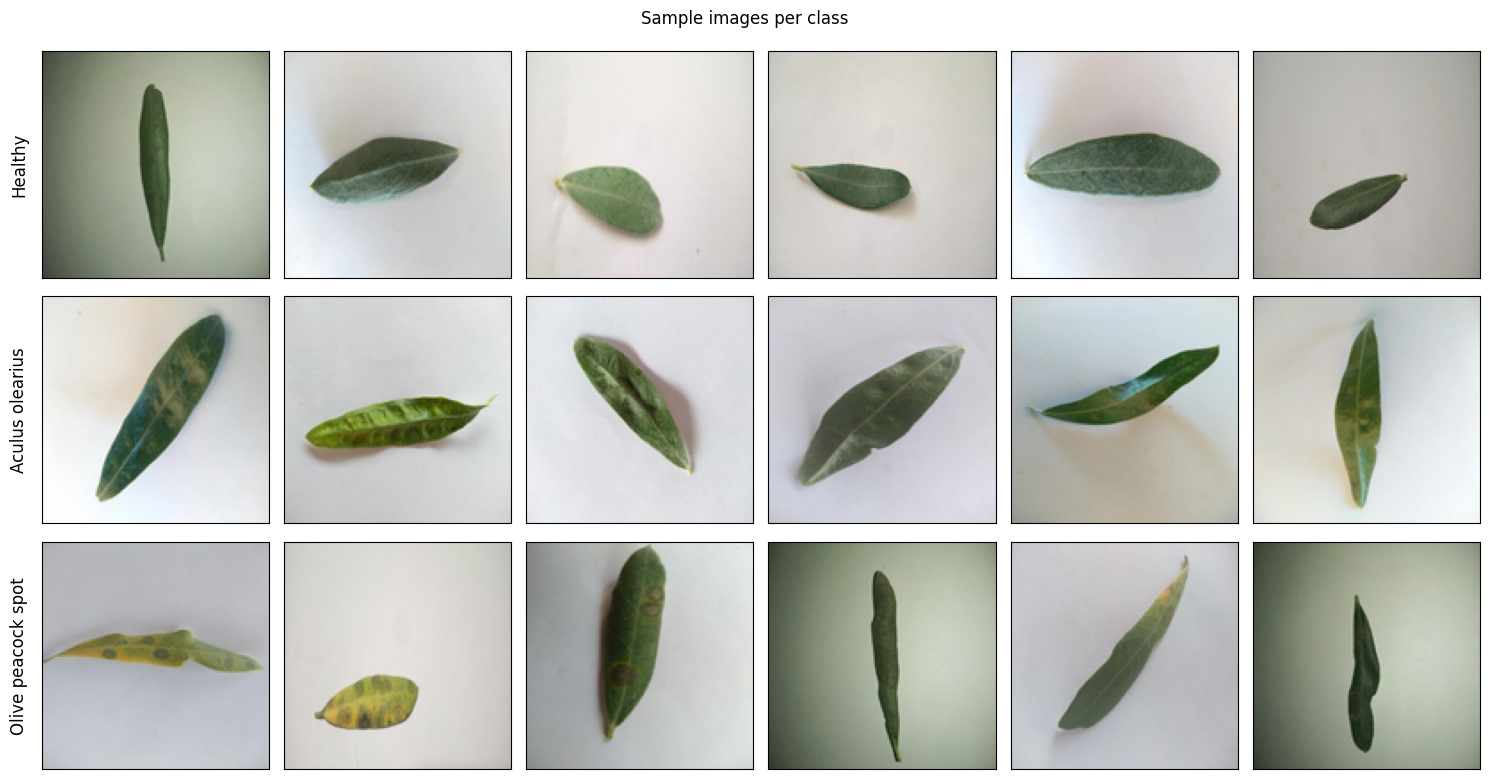

In [7]:
# Sample images per class
class_names = ['Healthy', 'Aculus olearius', 'Olive peacock spot']

# boolean mask per class from one-hot Y  (Y.argmax(1) gives the int label)
y_int = Y.argmax(axis=1)
masks = [y_int == 0, y_int == 1, y_int == 2]

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row, (mask, name) in enumerate(zip(masks, class_names)):
    for i, idx in enumerate(np.where(mask)[0][:6]):
        ax = axes[row, i]
        ax.imshow(X[idx])
        ax.set_xticks([]); ax.set_yticks([])   # hide ticks but KEEP the frame
        if i == 0:
            ax.set_ylabel(name, fontsize=12, rotation=90, labelpad=10)

plt.suptitle('Sample images per class')
plt.tight_layout()
plt.show()

In [2]:
# batch processing time!

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=10, zoom_range=0.1,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, vertical_flip=True, validation_split=0.3)
test_datagen = ImageDataGenerator(rescale=1./255)   # no augmentation

CLASSES = ['Healthy', 'aculus_olearius', 'olive_peacock_spot']

train_gen = train_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=8, class_mode='categorical', classes=CLASSES,
                subset='training', shuffle=True)
val_gen   = train_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=8, class_mode='categorical', classes=CLASSES,
                subset='validation', shuffle=False)
test_gen  = test_datagen.flow_from_directory('test', target_size=(w, h),
                batch_size=8, class_mode='categorical', classes=CLASSES,
                shuffle=False)

num_classes = len(CLASSES)

Found 1904 images belonging to 3 classes.
Found 816 images belonging to 3 classes.
Found 680 images belonging to 3 classes.


In [3]:
# confirm rescale is good

xb, yb = next(train_gen)
print(xb.min(), xb.max())

0.0015888561 0.99911565


Epoch 1/500


2026-07-21 00:30:04.878157: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 750 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:ca:00.0, compute capability: 8.6
2026-07-21 00:30:05.065179: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-07-21 00:30:05.769538: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-07-21 00:30:05.857155: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-07-21 00:30:05.936413: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only 

237/238 [============================>.] - ETA: 0s - loss: 0.9064 - acc: 0.5491

2026-07-21 00:30:16.462891: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


238/238 [==============================] - 16s 57ms/step - loss: 0.9055 - acc: 0.5488 - val_loss: 1.0145 - val_acc: 0.4914
Epoch 2/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7295 - acc: 0.6576 - val_loss: 1.0029 - val_acc: 0.5723
Epoch 3/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7032 - acc: 0.6775 - val_loss: 0.8285 - val_acc: 0.4963
Epoch 4/500
238/238 [==============================] - 13s 56ms/step - loss: 0.6656 - acc: 0.7022 - val_loss: 0.8614 - val_acc: 0.5319
Epoch 5/500
238/238 [==============================] - 13s 56ms/step - loss: 0.6580 - acc: 0.7117 - val_loss: 0.8813 - val_acc: 0.5306
Epoch 6/500
238/238 [==============================] - 14s 57ms/step - loss: 0.6112 - acc: 0.7290 - val_loss: 1.0195 - val_acc: 0.5625
Epoch 7/500
238/238 [==============================] - 13s 55ms/step - loss: 0.6266 - acc: 0.7190 - val_loss: 1.0926 - val_acc: 0.5600
Epoch 8/500
238/238 [==============================] - 13s 55ms/ste

...

238/238 [==============================] - 15s 56ms/step - loss: 0.9052 - acc: 0.5425 - val_loss: 1.2324 - val_acc: 0.6017
Epoch 2/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7307 - acc: 0.6245 - val_loss: 0.8376 - val_acc: 0.5221
Epoch 3/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7079 - acc: 0.6717 - val_loss: 0.8748 - val_acc: 0.5123
Epoch 4/500
238/238 [==============================] - 13s 54ms/step - loss: 0.6531 - acc: 0.6843 - val_loss: 0.9812 - val_acc: 0.5404
Epoch 5/500
238/238 [==============================] - 13s 55ms/step - loss: 0.6615 - acc: 0.7017 - val_loss: 1.0753 - val_acc: 0.5858
Epoch 6/500
238/238 [==============================] - 13s 53ms/step - loss: 0.5853 - acc: 0.7500 - val_loss: 1.1344 - val_acc: 0.5821
Epoch 7/500
238/238 [==============================] - 13s 55ms/step - loss: 0.5939 - acc: 0.7285 - val_loss: 0.8985 - val_acc: 0.5613
Epoch 8/500
238/238 [==============================] - 13s 53ms/ste

2026-07-21 00:57:00.120899: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


  1/102 [..............................] - ETA: 18s

2026-07-21 00:57:04.122286: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


102/102 [==============================] - 4s 40ms/step
>> T8_deep_wide_dense: val_loss=0.8554 val_acc=0.5172


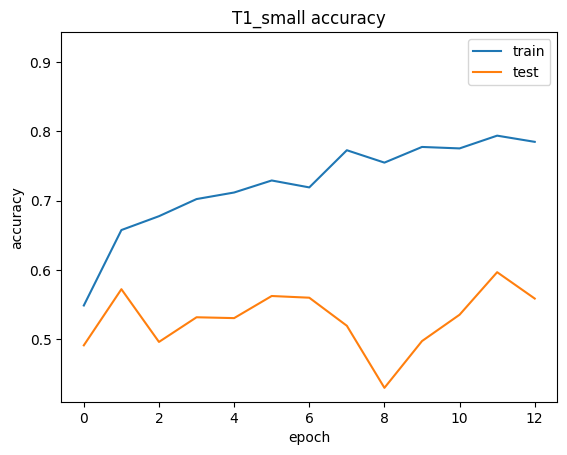

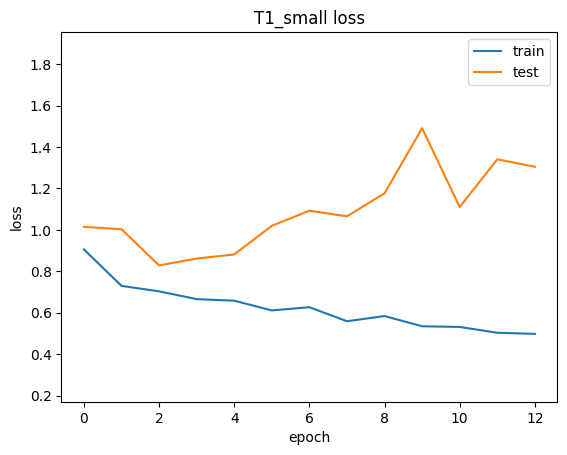

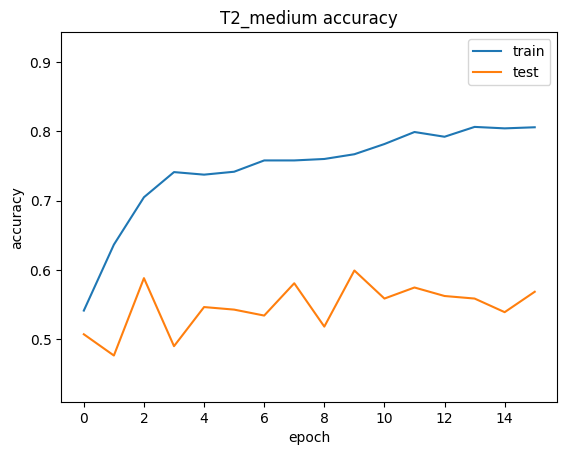

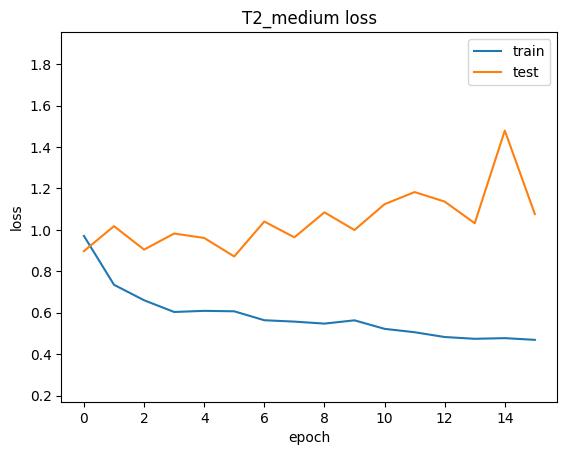

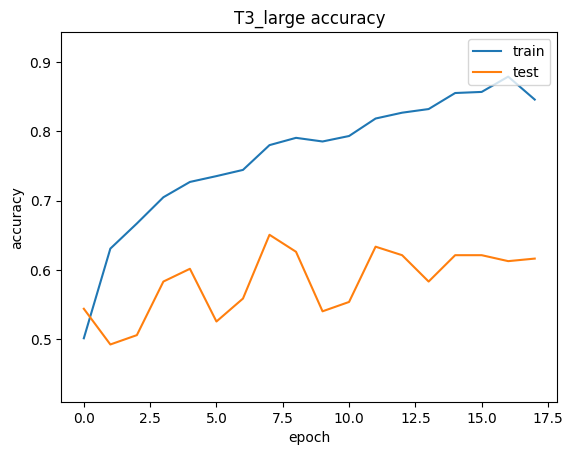

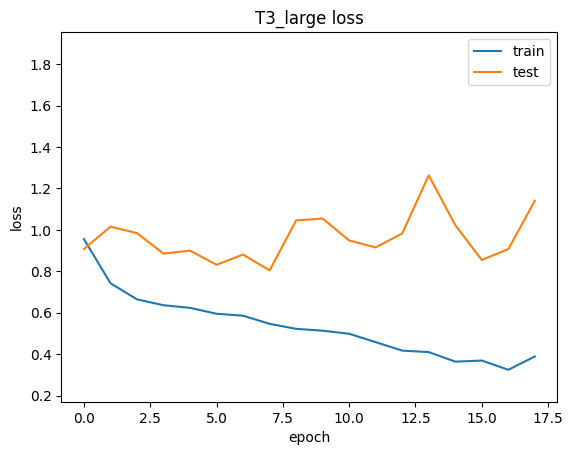

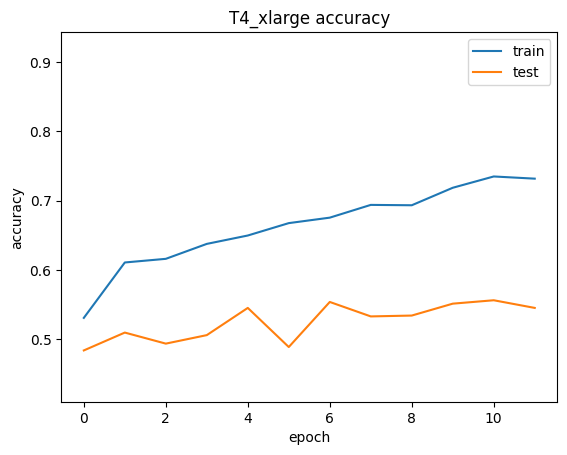

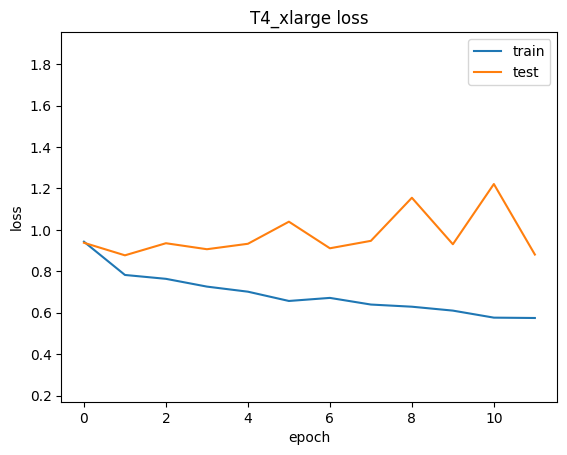

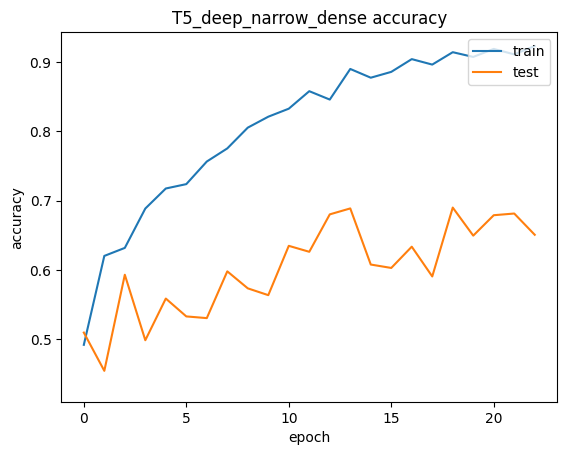

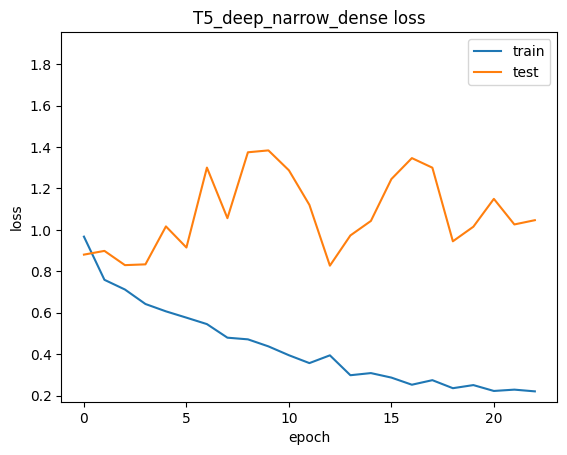

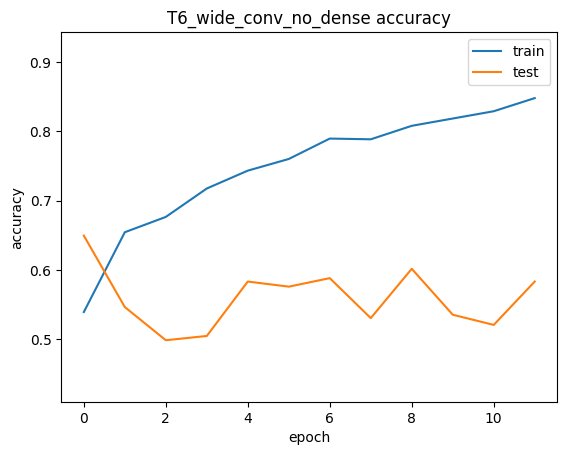

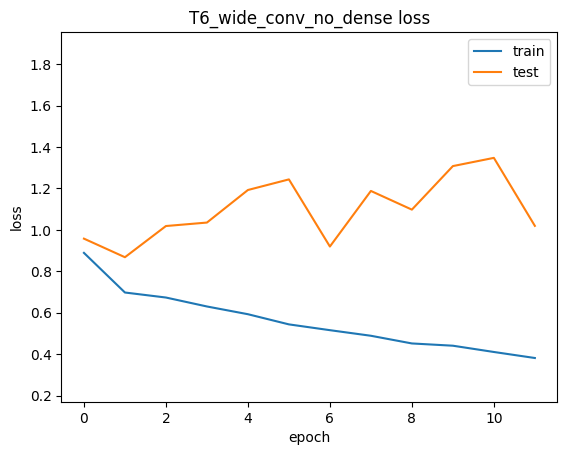

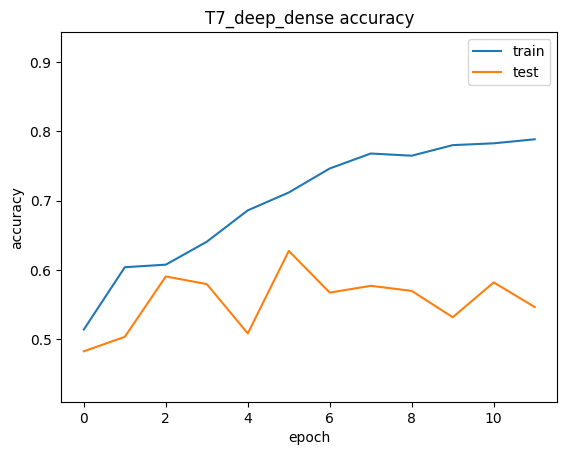

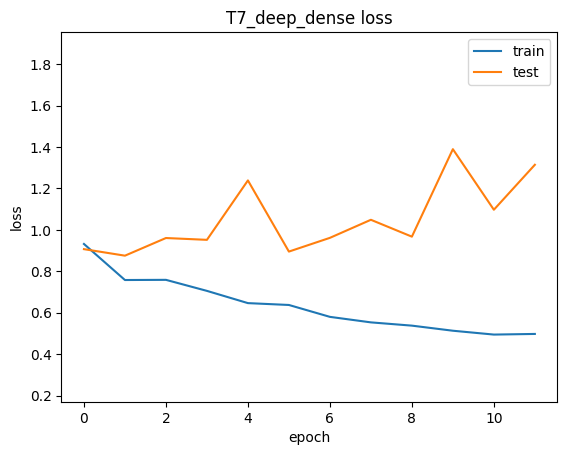

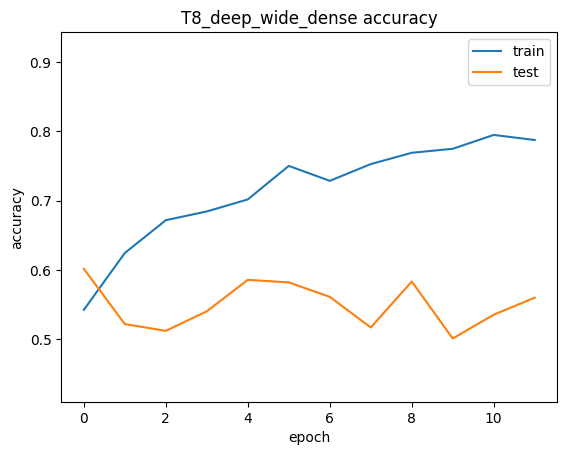

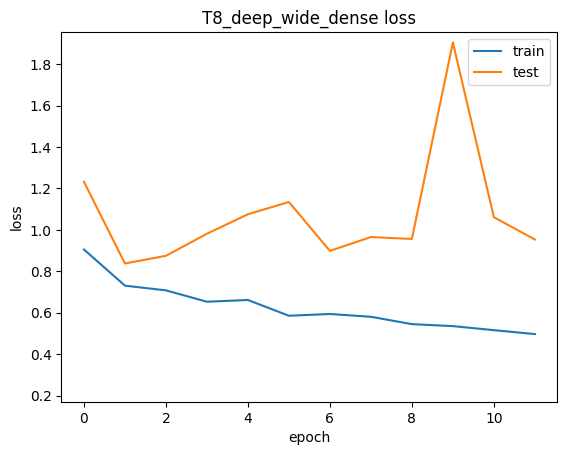

In [4]:
topologies = [
    {"name": "T1_small",  "conv_filters": [16, 32],       "dense_units": [64]},
    {"name": "T2_medium", "conv_filters": [32, 64],       "dense_units": [128]},
    {"name": "T3_large",  "conv_filters": [32, 64, 128],  "dense_units": [128, 64]},
    {"name": "T4_xlarge", "conv_filters": [64, 128, 256], "dense_units": [256, 128]},
    {"name": "T5_deep_narrow_dense", "conv_filters": [16, 32, 64, 128], "dense_units": [32]},
    {"name": "T6_wide_conv_no_dense", "conv_filters": [32, 64, 128],    "dense_units": []},
    {"name": "T7_deep_dense",      "conv_filters": [32, 64, 128], "dense_units": [128, 64, 32]},
    {"name": "T8_deep_wide_dense", "conv_filters": [32, 64, 128], "dense_units": [512, 256, 128]},
]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
num_classes = 3
topo_results, histories = [], {}

# train all topologies
for t in topologies:
    model = Sequential()
    first = True
    for f in t["conv_filters"]:
        if first:
            model.add(Conv2D(f, (3, 3), activation='relu', input_shape=(w, h, 3)))
            first = False
        else:
            model.add(Conv2D(f, (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    for u in t["dense_units"]:
        model.add(Dense(u, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
    results = model.fit(train_gen, validation_data=val_gen, epochs=500,
                        verbose=1, callbacks=[early_stopping])
    histories[t["name"]] = results.history

    # --- objective metrics at the RESTORED best-weights epoch ---
    val_gen.reset(); val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    val_gen.reset(); y_pred = model.predict(val_gen).argmax(axis=1)
    best_epoch = int(np.argmin(results.history['val_loss'])) + 1
    topo_results.append({
        "name": t["name"],
        "params": model.count_params(),
        "val_loss": round(val_loss, 4),
        "val_acc":  round(val_acc, 4),
        "epochs":   best_epoch,
    })
    print(f">> {t['name']}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

all_acc  = [v for h in histories.values() for v in (h['acc'] + h['val_acc'])]
all_loss = [v for h in histories.values() for v in (h['loss'] + h['val_loss'])]

acc_lo  = max(0.0, min(all_acc) - 0.02)
acc_hi  = min(1.0, max(all_acc) + 0.02)
loss_lo = max(0.0, min(all_loss) - 0.05)
loss_hi = max(all_loss) + 0.05

# plot everything on the same scale
for name, hist in histories.items():
    plt.plot(hist['acc'])
    plt.plot(hist['val_acc'])
    plt.title(f'{name} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.ylim(acc_lo, acc_hi)  
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

    plt.plot(hist['loss'])
    plt.plot(hist['val_loss'])
    plt.title(f'{name} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.ylim(loss_lo, loss_hi) 
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

Epoch 1/500


2026-07-21 01:16:25.314959: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


238/238 [==============================] - ETA: 0s - loss: 0.8786 - acc: 0.5636

2026-07-21 01:16:36.264032: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


238/238 [==============================] - 15s 56ms/step - loss: 0.8786 - acc: 0.5636 - val_loss: 0.8999 - val_acc: 0.4963
Epoch 2/500
238/238 [==============================] - 13s 55ms/step - loss: 0.7082 - acc: 0.6576 - val_loss: 0.9995 - val_acc: 0.5208
Epoch 3/500
238/238 [==============================] - 13s 54ms/step - loss: 0.6184 - acc: 0.6933 - val_loss: 0.9508 - val_acc: 0.5061
Epoch 4/500
238/238 [==============================] - 13s 54ms/step - loss: 0.5470 - acc: 0.7673 - val_loss: 1.1420 - val_acc: 0.5515
Epoch 5/500
238/238 [==============================] - 13s 54ms/step - loss: 0.5388 - acc: 0.7705 - val_loss: 1.0986 - val_acc: 0.5123
Epoch 6/500
238/238 [==============================] - 13s 53ms/step - loss: 0.4905 - acc: 0.7836 - val_loss: 1.0501 - val_acc: 0.5699
Epoch 7/500
238/238 [==============================] - 14s 57ms/step - loss: 0.4788 - acc: 0.8120 - val_loss: 1.0319 - val_acc: 0.6127
Epoch 8/500
238/238 [==============================] - 13s 54ms/ste

...

238/238 [==============================] - 15s 55ms/step - loss: 1.0880 - acc: 0.4244 - val_loss: 1.1074 - val_acc: 0.4412
Epoch 2/500
238/238 [==============================] - 13s 53ms/step - loss: 1.0667 - acc: 0.4433 - val_loss: 1.1653 - val_acc: 0.3419
Epoch 3/500
238/238 [==============================] - 13s 55ms/step - loss: 1.0548 - acc: 0.4601 - val_loss: 1.0738 - val_acc: 0.4412
Epoch 4/500
238/238 [==============================] - 13s 53ms/step - loss: 1.0430 - acc: 0.4669 - val_loss: 1.1001 - val_acc: 0.4167
Epoch 5/500
238/238 [==============================] - 12s 52ms/step - loss: 0.9623 - acc: 0.4989 - val_loss: 0.8889 - val_acc: 0.4963
Epoch 6/500
238/238 [==============================] - 13s 53ms/step - loss: 0.8259 - acc: 0.5851 - val_loss: 0.8322 - val_acc: 0.4975
Epoch 7/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7634 - acc: 0.6161 - val_loss: 0.8857 - val_acc: 0.4828
Epoch 8/500
238/238 [==============================] - 13s 53ms/ste

2026-07-21 01:35:50.889721: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


  1/102 [..............................] - ETA: 18s

2026-07-21 01:35:55.012588: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


102/102 [==============================] - 4s 37ms/step
>> K3_kernel7: val_loss=0.7793 val_acc=0.5809


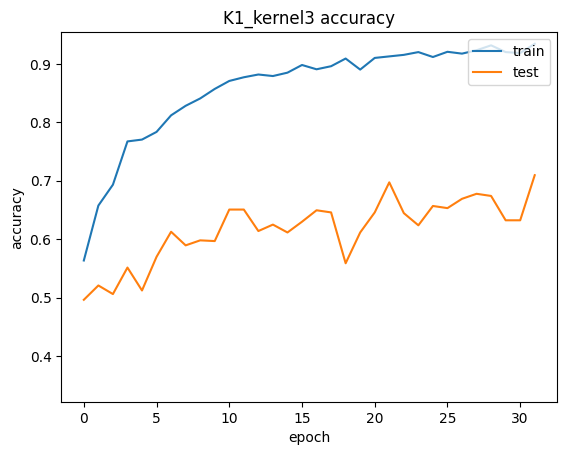

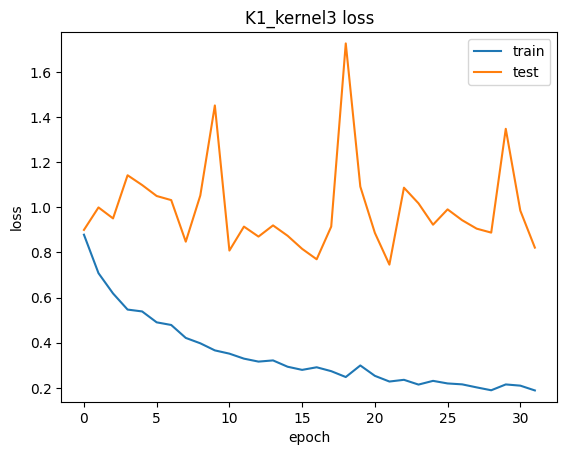

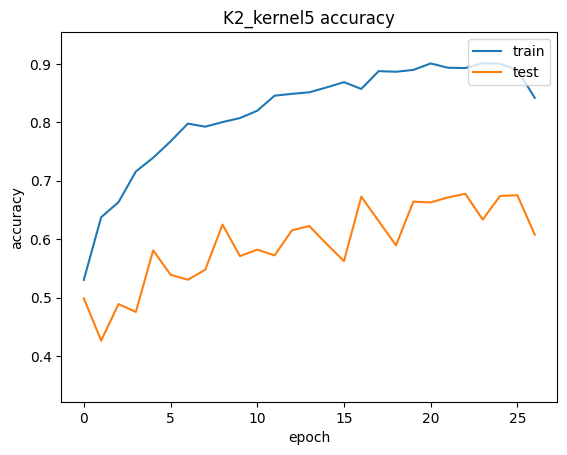

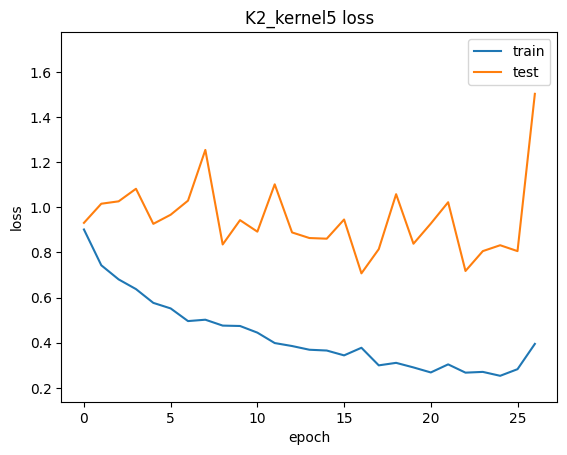

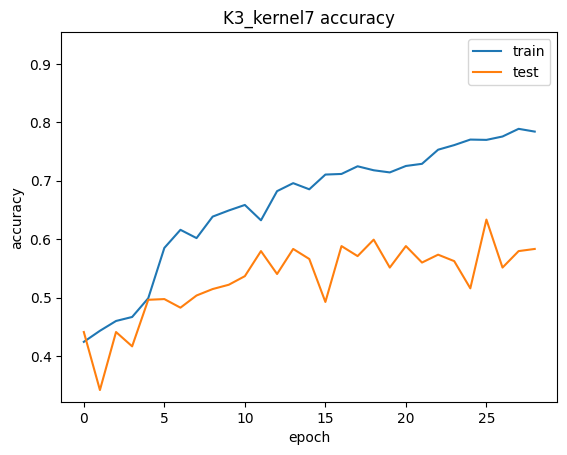

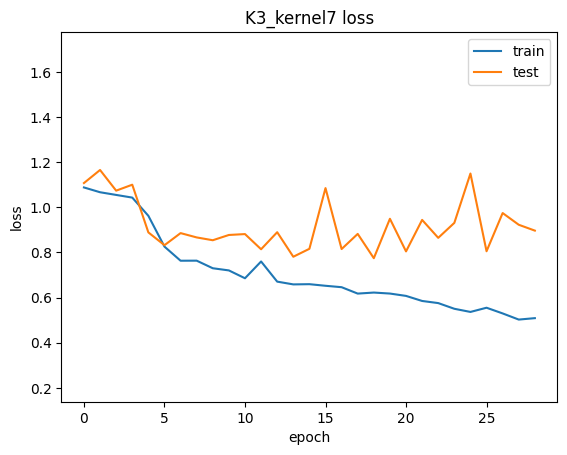

In [7]:
# Kernel exploration, BEST topology net: {"name": "T5_deep_narrow_dense", "conv_filters": [16, 32, 64, 128], "dense_units": [32]}
BEST_CONV = [16, 32, 64, 128]
BEST_DENSE = [32]

w = 128
h = 128

topologies = [
    {"name": "K1_kernel3", "conv_filters": [16, 32, 64, 128], "dense_units": [32], "kernel": 3},
    {"name": "K2_kernel5", "conv_filters": [16, 32, 64, 128], "dense_units": [32], "kernel": 5},
    {"name": "K3_kernel7", "conv_filters": [16, 32, 64, 128], "dense_units": [32], "kernel": 7},
]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
num_classes = 3
topo_results, histories = [], {}

# train all topologies
for t in topologies:
    model = Sequential()
    first = True
    for f in t["conv_filters"]:
        k = t.get("kernel", 3)          
        if first:
            model.add(Conv2D(f, (k, k), activation='relu', input_shape=(w, h, 3)))
            first = False
        else:
            model.add(Conv2D(f, (k, k), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    for u in t["dense_units"]:
        model.add(Dense(u, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
    results = model.fit(train_gen, validation_data=val_gen, epochs=500,
                        verbose=1, callbacks=[early_stopping])
    histories[t["name"]] = results.history

    # --- objective metrics at the RESTORED best-weights epoch ---
    val_gen.reset(); val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    val_gen.reset(); y_pred = model.predict(val_gen).argmax(axis=1)
    best_epoch = int(np.argmin(results.history['val_loss'])) + 1
    topo_results.append({
        "name": t["name"],
        "params": model.count_params(),
        "val_loss": round(val_loss, 4),
        "val_acc":  round(val_acc, 4),
        "epochs":   best_epoch,
    })
    print(f">> {t['name']}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

all_acc  = [v for h in histories.values() for v in (h['acc'] + h['val_acc'])]
all_loss = [v for h in histories.values() for v in (h['loss'] + h['val_loss'])]

acc_lo  = max(0.0, min(all_acc) - 0.02)
acc_hi  = min(1.0, max(all_acc) + 0.02)
loss_lo = max(0.0, min(all_loss) - 0.05)
loss_hi = max(all_loss) + 0.05

# plot everything on the same scale
for name, hist in histories.items():
    plt.plot(hist['acc'])
    plt.plot(hist['val_acc'])
    plt.title(f'{name} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.ylim(acc_lo, acc_hi)  
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

    plt.plot(hist['loss'])
    plt.plot(hist['val_loss'])
    plt.title(f'{name} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.ylim(loss_lo, loss_hi) 
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

<p>We chose kernel 5x5 as the best kernel size to move with. Kernel 3x3 showed a lot of promise on the accuracy curve, to a point where it looked slightly better than 5x5. This is because the acc curves not only achieve a higher accuracy in the end, but they also end showing an upward tragectory. Though when compared to 5x5, by epoch 25, even though it attained a higher accuracy, the loss curves when compared showed a contrast where 3x3 had a noisier test loss curve as compared to 5x5. Not only that but 3x3 hit higher loss value, which is bad because we need less loss to converge.</p>

<p>When we compare 5x5 to 7x7, the loss curves was the decider. Even though 7x7 has the loss curves close to each other, I belive the plot of training loss continues to decrease with experience, while the plot of validation loss decreases to a point and begins increasing again quite early in the epochs. On contrast the 5x5 even though it has a more considerable gain between its loss curves, the margin remaind relatively from about epoch 3 to about epoch 22 where it really starts to diverge.</p>

<p><b>Hence, kernel 5x5 was picked as the best kernel</b></p>

In [8]:
# regularization to try bring down the overfitting

from tensorflow.keras.layers import GaussianNoise, Dropout

# Regularization exploration: dropout vs noise, BEST topology net: T5_deep_narrow_dense
BEST_CONV  = [16, 32, 64, 128]
BEST_DENSE = [32]

topologies = [
    {"name": "R1_baseline_noreg",  "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.0, "noise": 0.0, "kernel": 5},
    {"name": "R2_dropout_light",   "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.2, "noise": 0.0, "kernel": 5},
    {"name": "R3_dropout_heavy",   "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.5, "noise": 0.0, "kernel": 5},
    {"name": "R4_noise_only",      "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.0, "noise": 0.1, "kernel": 5},
    {"name": "R5_dropout_and_noise","conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.2, "noise": 0.1, "kernel": 5},
]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
# num_classes = 3
topo_results, histories = [], {}

for t in topologies:
    model = Sequential()
    noise_std = t.get("noise", 0.0)
    dropout_rate = t.get("dropout", 0.0)
    k = t.get("kernel", 3)

    first = True
    for f in t["conv_filters"]:
        if first:
            # noise applied to the raw (rescaled) input, before the first conv
            model.add(GaussianNoise(noise_std, input_shape=(w, h, 3)))
            model.add(Conv2D(f, (k, k), activation='relu'))
            first = False
        else:
            model.add(Conv2D(f, (k, k), activation='relu'))
        model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    for u in t["dense_units"]:
        model.add(Dense(u, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

    results = model.fit(train_gen, validation_data=val_gen, epochs=500,
                        verbose=1, callbacks=[early_stopping])
    histories[t["name"]] = results.history

    val_gen.reset(); val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    val_gen.reset(); y_pred = model.predict(val_gen).argmax(axis=1)
    best_epoch = int(np.argmin(results.history['val_loss'])) + 1
    topo_results.append({
        "name": t["name"],
        "params": model.count_params(),
        "val_loss": round(val_loss, 4),
        "val_acc":  round(val_acc, 4),
        "epochs":   best_epoch,
    })
    print(f">> {t['name']}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 1/500


2026-07-21 02:07:28.511487: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


238/238 [==============================] - ETA: 0s - loss: 1.0829 - acc: 0.4391

2026-07-21 02:07:39.273772: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


238/238 [==============================] - 15s 54ms/step - loss: 1.0829 - acc: 0.4391 - val_loss: 1.0766 - val_acc: 0.4412
Epoch 2/500
238/238 [==============================] - 13s 54ms/step - loss: 0.9857 - acc: 0.4370 - val_loss: 1.0924 - val_acc: 0.3051
Epoch 3/500
238/238 [==============================] - 13s 54ms/step - loss: 1.0786 - acc: 0.4391 - val_loss: 1.0720 - val_acc: 0.4412
Epoch 4/500
238/238 [==============================] - 13s 54ms/step - loss: 1.0743 - acc: 0.4412 - val_loss: 1.0791 - val_acc: 0.4412
Epoch 5/500
238/238 [==============================] - 13s 55ms/step - loss: 1.0762 - acc: 0.4412 - val_loss: 1.0712 - val_acc: 0.4412
Epoch 6/500
238/238 [==============================] - 13s 54ms/step - loss: 1.0724 - acc: 0.4412 - val_loss: 1.0716 - val_acc: 0.4412
Epoch 7/500
238/238 [==============================] - 13s 54ms/step - loss: 1.0703 - acc: 0.4412 - val_loss: 1.0557 - val_acc: 0.4412
Epoch 8/500
238/238 [==============================] - 13s 54ms/ste

...

238/238 [==============================] - 15s 55ms/step - loss: 1.0783 - acc: 0.4301 - val_loss: 1.7106 - val_acc: 0.4412
Epoch 2/500
238/238 [==============================] - 13s 55ms/step - loss: 0.9119 - acc: 0.4669 - val_loss: 0.8963 - val_acc: 0.5098
Epoch 3/500
238/238 [==============================] - 13s 54ms/step - loss: 0.8195 - acc: 0.5956 - val_loss: 0.9395 - val_acc: 0.5000
Epoch 4/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7107 - acc: 0.6450 - val_loss: 0.8419 - val_acc: 0.5539
Epoch 5/500
238/238 [==============================] - 13s 53ms/step - loss: 0.6788 - acc: 0.6623 - val_loss: 0.8923 - val_acc: 0.5686
Epoch 6/500
238/238 [==============================] - 13s 55ms/step - loss: 0.7003 - acc: 0.6497 - val_loss: 0.9500 - val_acc: 0.5306
Epoch 7/500
238/238 [==============================] - 13s 55ms/step - loss: 0.6529 - acc: 0.6817 - val_loss: 0.9759 - val_acc: 0.4963
Epoch 8/500
238/238 [==============================] - 13s 54ms/ste

2026-07-21 02:29:12.890789: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


  1/102 [..............................] - ETA: 19s

2026-07-21 02:29:16.887660: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


102/102 [==============================] - 4s 37ms/step
>> R5_dropout_and_noise: val_loss=0.8379 val_acc=0.5613


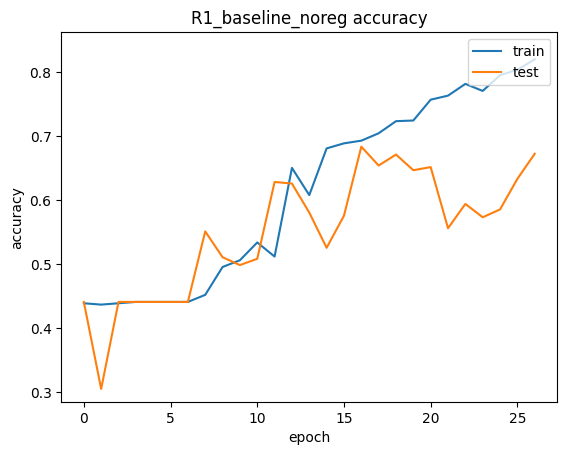

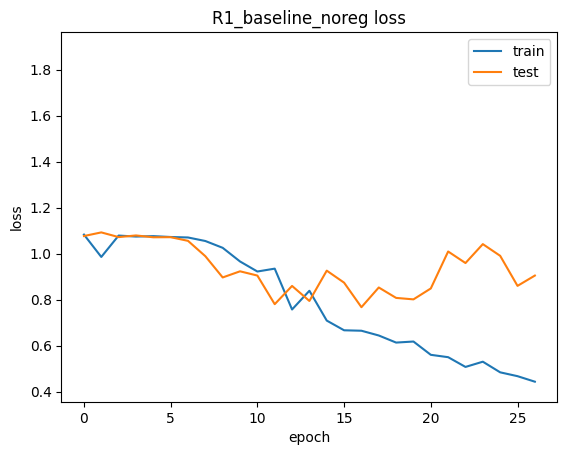

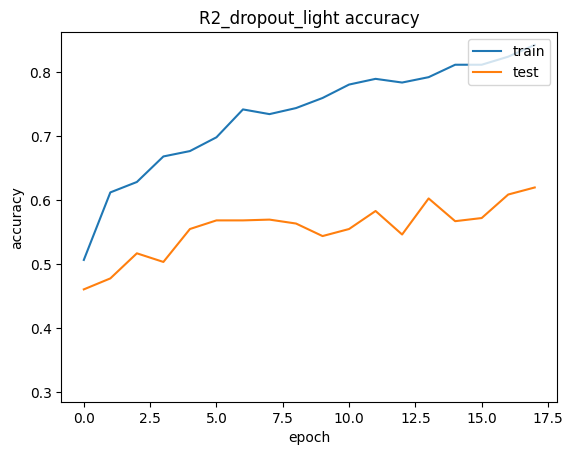

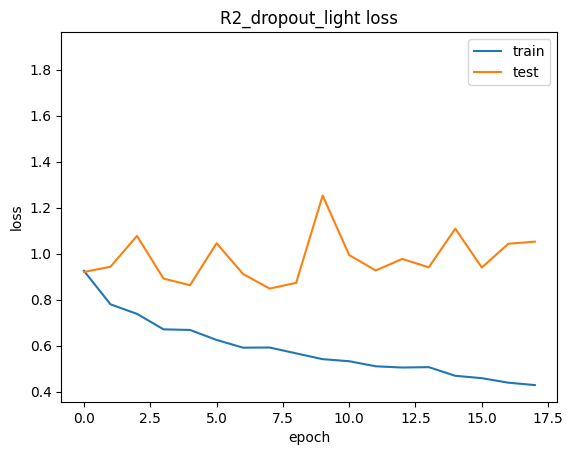

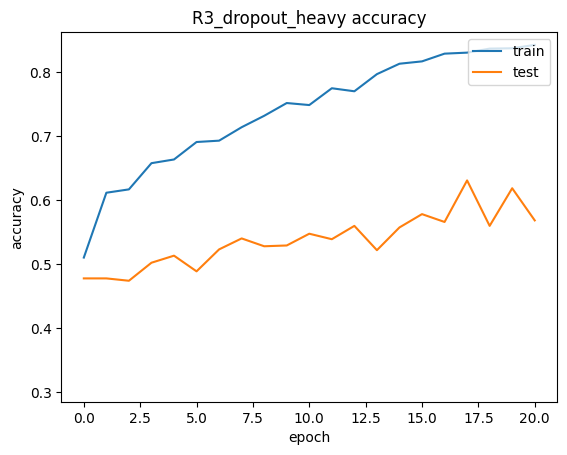

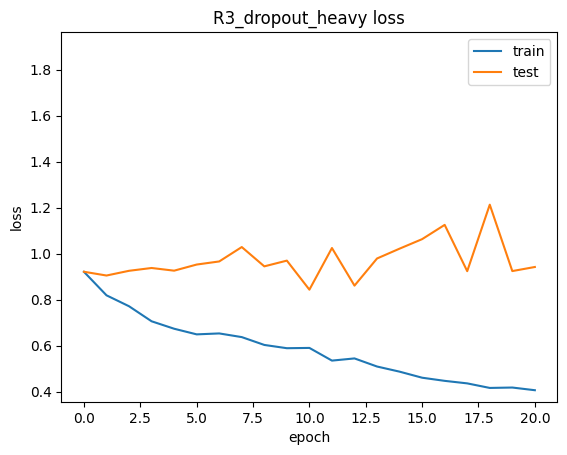

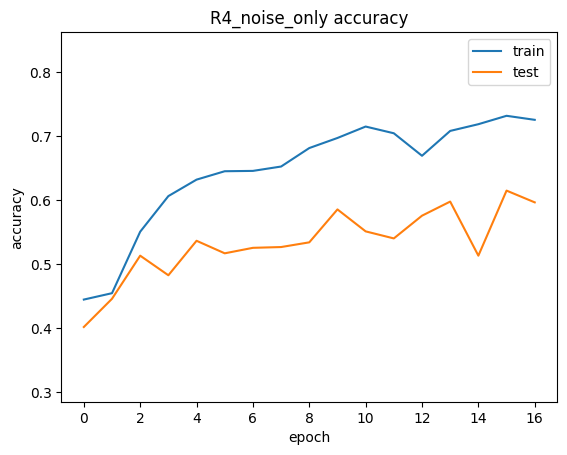

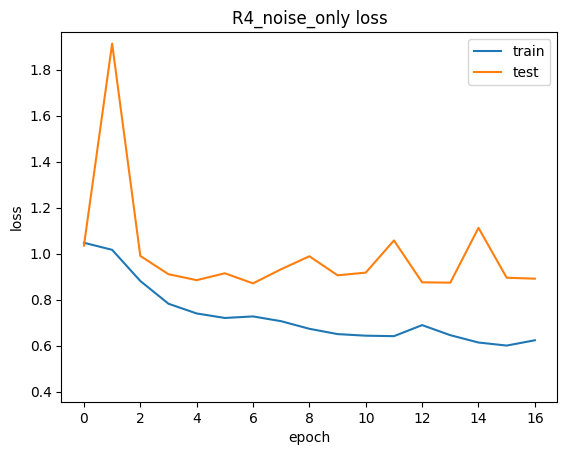

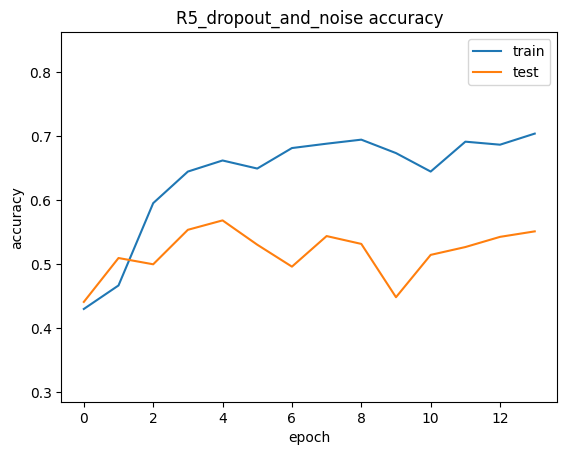

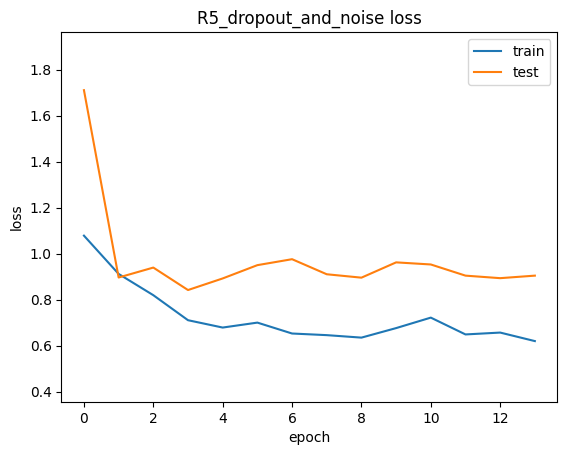

In [9]:
all_acc  = [v for hist in histories.values() for v in (hist['acc'] + hist['val_acc'])]
all_loss = [v for hist in histories.values() for v in (hist['loss'] + hist['val_loss'])]

acc_lo  = max(0.0, min(all_acc) - 0.02)
acc_hi  = min(1.0, max(all_acc) + 0.02)
loss_lo = max(0.0, min(all_loss) - 0.05)
loss_hi = max(all_loss) + 0.05

# plot everything on the same scale
for name, hist in histories.items():
    plt.plot(hist['acc'])
    plt.plot(hist['val_acc'])
    plt.title(f'{name} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.ylim(acc_lo, acc_hi)  
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

    plt.plot(hist['loss'])
    plt.plot(hist['val_loss'])
    plt.title(f'{name} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.ylim(loss_lo, loss_hi) 
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

- 

2026-07-21 15:02:01.083994: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 750 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:ca:00.0, compute capability: 8.6
2026-07-21 15:02:01.299494: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


Epoch 1/500


2026-07-21 15:02:02.156329: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-07-21 15:02:02.245010: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-07-21 15:02:02.365922: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-07-21 15:02:02.395993: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f7160044f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-21 15:02:02.396050: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
2026-07-21 15:02:02.408196: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-21 15:02:02.519695: I tensorfl

237/238 [============================>.] - ETA: 0s - loss: 0.9664 - acc: 0.4715

2026-07-21 15:02:13.985131: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


238/238 [==============================] - 17s 59ms/step - loss: 0.9663 - acc: 0.4722 - val_loss: 0.9268 - val_acc: 0.4988
Epoch 2/500
238/238 [==============================] - 13s 54ms/step - loss: 0.7743 - acc: 0.6224 - val_loss: 0.9120 - val_acc: 0.5012
Epoch 3/500
238/238 [==============================] - 13s 55ms/step - loss: 0.7722 - acc: 0.6239 - val_loss: 0.9254 - val_acc: 0.5061
Epoch 4/500
238/238 [==============================] - 13s 56ms/step - loss: 0.6921 - acc: 0.6602 - val_loss: 0.9145 - val_acc: 0.5306
Epoch 5/500
238/238 [==============================] - 13s 55ms/step - loss: 0.6571 - acc: 0.6870 - val_loss: 0.9709 - val_acc: 0.5098
Epoch 6/500
238/238 [==============================] - 14s 57ms/step - loss: 0.6309 - acc: 0.7106 - val_loss: 0.8587 - val_acc: 0.5846
Epoch 7/500
238/238 [==============================] - 13s 55ms/step - loss: 0.6568 - acc: 0.6949 - val_loss: 0.9062 - val_acc: 0.5527
Epoch 8/500
238/238 [==============================] - 13s 55ms/ste

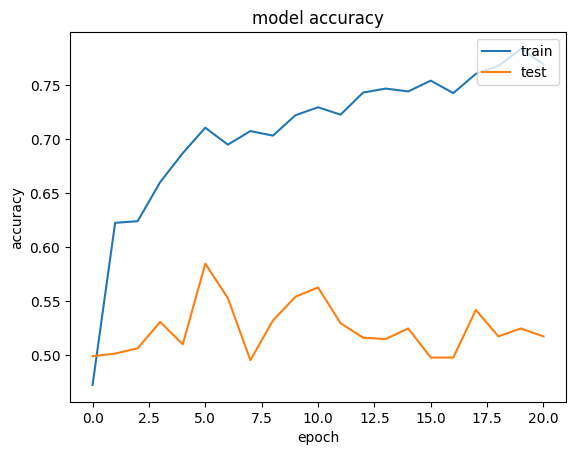

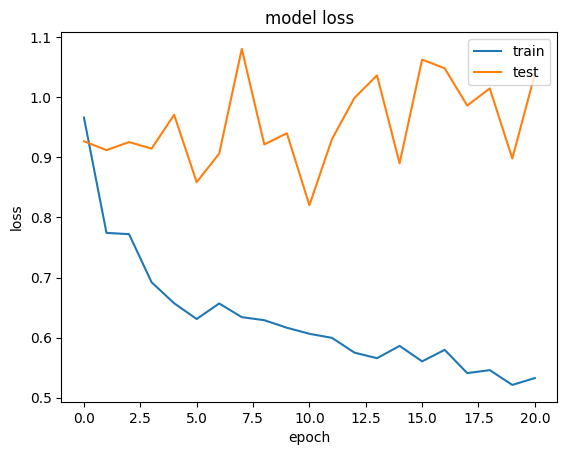

In [4]:
# Best model

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

modelBest = Sequential()
modelBest.add(GaussianNoise(0.1, input_shape=(w, h, 3)))
modelBest.add(Conv2D(16, (5, 5), activation='relu'))
modelBest.add(MaxPooling2D((2, 2)))
modelBest.add(Conv2D(32, (5, 5), activation='relu'))
modelBest.add(MaxPooling2D((2, 2)))
modelBest.add(Conv2D(64, (5, 5), activation='relu'))
modelBest.add(MaxPooling2D((2, 2)))
modelBest.add(Conv2D(128, (5, 5), activation='relu'))
modelBest.add(MaxPooling2D((2, 2)))
modelBest.add(Flatten())
modelBest.add(Dense(32, activation='relu'))
modelBest.add(Dropout(0.2))
modelBest.add(Dense(num_classes, activation='softmax'))
modelBest.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

# Fit the model
results = modelBest.fit(train_gen, validation_data=val_gen, epochs=500, verbose=1, callbacks=[early_stopping])

plt.plot(results.history['acc'])
plt.plot(results.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [5]:
# Saving the model
import time

ts = int(time.time())
file_path = f"productionModel/{ts}/"
modelBest.save(filepath=file_path, save_format='tf')

2026-07-21 15:41:16.819738: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gaussian_noise_input' with dtype float and shape [?,128,128,3]
	 [[{{node gaussian_noise_input}}]]
2026-07-21 15:41:16.905452: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,128,128,3]
	 [[{{node inputs}}]]
2026-07-21 15:41:16.928041: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gaussian_noise_input' with dtype float an

INFO:tensorflow:Assets written to: productionModel/1784644876/assets


INFO:tensorflow:Assets written to: productionModel/1784644876/assets


In [6]:
ts = str(int(time.time()))
file_path = ts
modelBest.save(filepath=file_path, save_format='tf')

#creates a zip file which can be downloaded and unzipped
import shutil
shutil.make_archive(ts, 'zip', ts)

2026-07-21 15:41:20.552149: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gaussian_noise_input' with dtype float and shape [?,128,128,3]
	 [[{{node gaussian_noise_input}}]]
2026-07-21 15:41:20.637052: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,128,128,3]
	 [[{{node inputs}}]]
2026-07-21 15:41:20.659447: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gaussian_noise_input' with dtype float an

INFO:tensorflow:Assets written to: 1784644880/assets


INFO:tensorflow:Assets written to: 1784644880/assets


'/home/a00049549/kq_tf/a00049549_CA3/1784644880.zip'